In [2]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google'

# Algoritma Genetika — Rekomendasi Paket Wisata Yogyakarta

| Komponen | Detail |
|---|---|
| Dataset Lokasi | `lokasi_wisata.csv` — 50 lokasi, 8 kategori utama |
| Dataset Jarak | `matriks_jarak.csv` — 2.450 pasangan jarak riil (km) + waktu tempuh (menit) |
| Representasi GA | Permutasi N ID lokasi |
| Crossover | Order Crossover (OX) |
| Mutasi | Swap Mutation |
| Seleksi | Rank Selection + Elitism |

## Cell 1 — Import Library

In [17]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
print("✅ Library berhasil di-import!")

✅ Library berhasil di-import!


## Cell 2 — Load Dataset

In [20]:
# LOAD DATASET LOKASI WISATA

df = pd.read_csv('Dataset Wisata Yogyakarta - lokasi_wisata.csv')

# --- Konversi jam string → float ---
def jam_str_to_float(s):
    s = str(s).strip()
    parts = s.split(':')
    h = int(parts[0])
    m = int(parts[1]) if len(parts) > 1 else 0
    return h + m / 60

df['jam_buka']  = df['jam_buka'].apply(jam_str_to_float)
df['jam_tutup'] = df['jam_tutup'].apply(jam_str_to_float)

# --- Konversi durasi menit → jam ---
df['durasi_jam'] = df['durasi_menit'] / 60

# --- Pisah kolom latitude_longitude → dua kolom terpisah ---
def parse_latlon(s):
    try:
        lat, lon = str(s).replace('"','').split(',')
        return float(lat.strip()), float(lon.strip())
    except:
        return 0.0, 0.0

latlon = df['latitude_longitude'].apply(parse_latlon)
df['lat'] = latlon.apply(lambda x: x[0])
df['lon'] = latlon.apply(lambda x: x[1])

# --- Buat indeks integer 0..N-1 dari id_lokasi string ---
id_list   = df['id_lokasi'].tolist()
id_to_idx = {id_: i for i, id_ in enumerate(id_list)}   # string → int
idx_to_id = {i: id_ for i, id_ in enumerate(id_list)}   # int → string

# --- Mapping kategori detail → kategori UTAMA ---
KATEGORI_UTAMA = {
    'Belanja / Ikonik'    : 'Ikonik',
    'Ikonik'              : 'Ikonik',
    'Sejarah / Candi'     : 'Sejarah',
    'Sejarah / Budaya'    : 'Sejarah',
    'Sejarah / Spot Foto' : 'Sejarah',
    'Sejarah / Museum'    : 'Sejarah',
    'Pantai / Alam'       : 'Pantai',
    'Alam / Spot Foto'    : 'Alam',
    'Alam / Susur Goa'    : 'Alam',
    'Alam / Air Terjun'   : 'Alam',
    'Alam / Kuliner'      : 'Alam',
    'Alam / Taman'        : 'Alam',
    'Alam / Pegunungan'   : 'Alam',
    'Alam / Danau'        : 'Alam',
    'Kafe / Spot Foto'    : 'Kafe',
    'Kafe / Alam'         : 'Kafe',
    'Spot Foto / Hiburan' : 'Hiburan',
    'Spot Foto / Edukasi' : 'Hiburan',
    'Hiburan Malam'       : 'Hiburan',
    'Hiburan / Wahana'    : 'Hiburan',
    'Hiburan / Air'       : 'Hiburan',
    'Kebun Binatang'      : 'Hiburan',
}
df['kategori_utama'] = df['kategori'].map(KATEGORI_UTAMA).fillna('Lainnya')

N = len(df)
print(f"✅ Dataset berhasil dimuat!")
print(f"   Jumlah lokasi (N)  : {N}")
print(f"   Kolom tersedia     : {list(df.columns)}")
print(f"\nDistribusi Kategori Utama:")
print(df['kategori_utama'].value_counts().to_string())
print(f"\nRentang Harga Tiket:")
for kat in df['kategori_utama'].unique():
    sub = df[df['kategori_utama']==kat]['harga_tiket']
    print(f"   {kat:<10}: Rp {int(sub.min()):>6,} – Rp {int(sub.max()):>6,}")

✅ Dataset berhasil dimuat!
   Jumlah lokasi (N)  : 50
   Kolom tersedia     : ['id_lokasi', 'nama_lokasi', 'kategori', 'harga_tiket', 'jam_buka', 'jam_tutup', 'durasi_menit', 'latitude_longitude', 'durasi_jam', 'lat', 'lon', 'kategori_utama']

Distribusi Kategori Utama:
kategori_utama
Sejarah    18
Pantai     10
Alam       10
Hiburan     6
Ikonik      3
Kafe        3

Rentang Harga Tiket:
   Ikonik    : Rp      0 – Rp      0
   Sejarah   : Rp      0 – Rp 50,000
   Pantai    : Rp  5,000 – Rp 15,000
   Alam      : Rp      0 – Rp 40,000
   Kafe      : Rp 20,000 – Rp 25,000
   Hiburan   : Rp      0 – Rp 85,000


## Cell 3 — Load Matriks Jarak dari CSV

   Matriks jarak berhasil dibuat!
   Ukuran matrix       : 50×50
   Pasangan dimuat     : 2450 / 2450
   Pasangan tidak cocok: 0
   Jarak min (non-zero): 0.18 km
   Jarak maksimum      : 109.91 km
   Waktu tempuh maks   : 88 menit


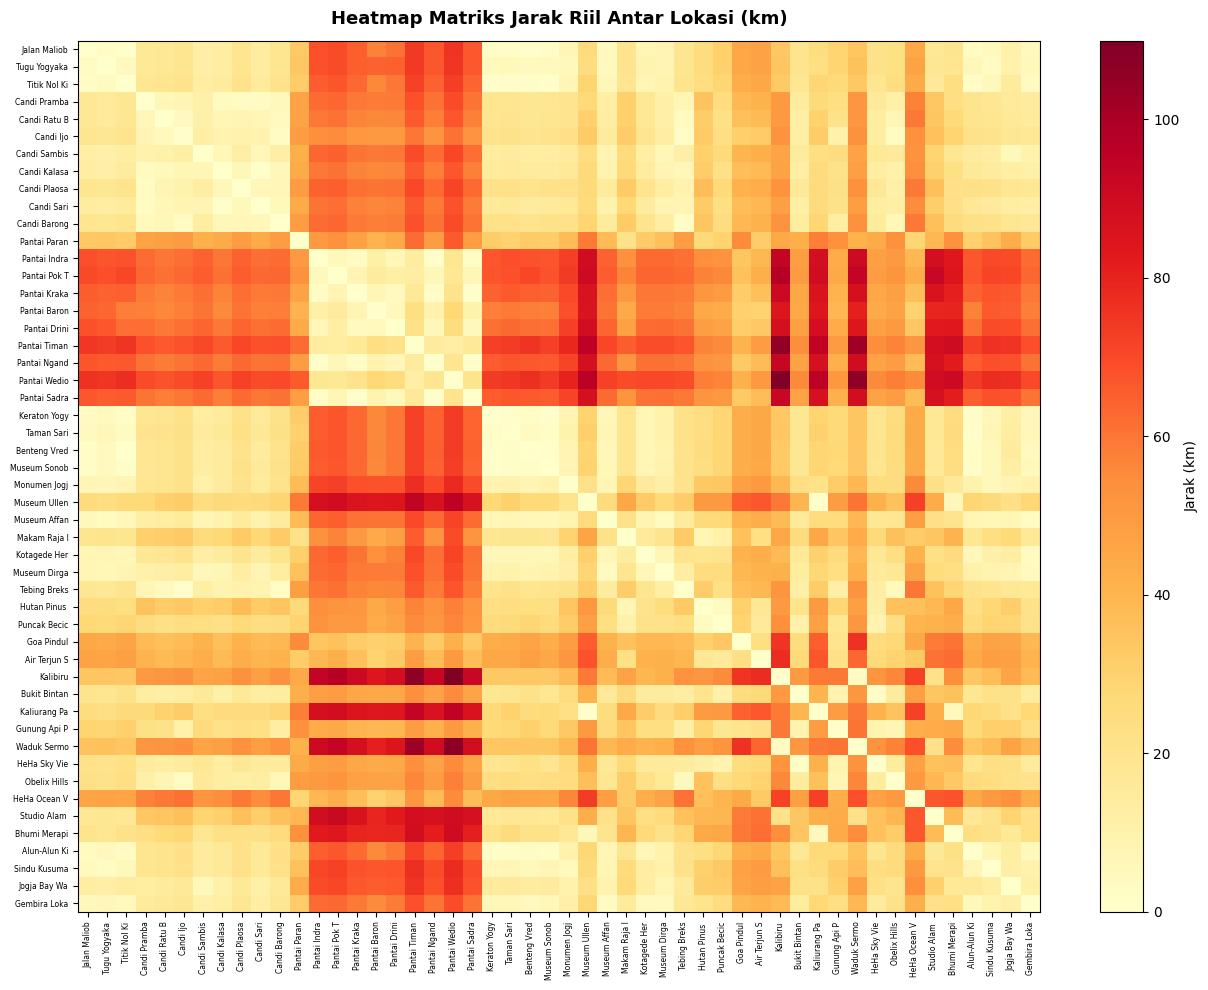

Heatmap berhasil ditampilkan!


In [21]:
# LOAD MATRIKS JARAK RIIL

dm_raw = pd.read_csv('Dataset Wisata Yogyakarta - matriks_jarak.csv')

# --- Perbaiki format desimal koma → titik ---
def parse_jarak(val):
    try:
        return float(str(val).replace(',', '.'))
    except:
        return 0.0

dm_raw['jarak_km_float'] = dm_raw['jarak_km'].apply(parse_jarak)

# --- Bangun matrix numpy N×N dari data long-format CSV ---
dist_matrix         = np.zeros((N, N))
travel_time_matrix  = np.zeros((N, N))

missing = 0  # counter pasangan yang tidak ditemukan di CSV
for _, row in dm_raw.iterrows():
    asal   = row['id_lokasi_asal']
    tujuan = row['id_lokasi_tujuan']
    # Pastikan kedua ID ada di pemetaan kita
    if asal in id_to_idx and tujuan in id_to_idx:
        i = id_to_idx[asal]
        j = id_to_idx[tujuan]
        dist_matrix[i][j]        = row['jarak_km_float']
        travel_time_matrix[i][j] = row['waktu_tempuh_menit'] / 60  # menit → jam
    else:
        missing += 1

print(f"   Matriks jarak berhasil dibuat!")
print(f"   Ukuran matrix       : {N}×{N}")
print(f"   Pasangan dimuat     : {len(dm_raw) - missing} / {len(dm_raw)}")
print(f"   Pasangan tidak cocok: {missing}")
print(f"   Jarak min (non-zero): {dist_matrix[dist_matrix>0].min():.2f} km")
print(f"   Jarak maksimum      : {dist_matrix.max():.2f} km")
print(f"   Waktu tempuh maks   : {travel_time_matrix.max()*60:.0f} menit")

# --- Visualisasi heatmap ---
fig, ax = plt.subplots(figsize=(13, 10))
im = ax.imshow(dist_matrix, cmap='YlOrRd', aspect='auto')
plt.colorbar(im, ax=ax, label='Jarak (km)')
names_short = [df.iloc[i]['nama_lokasi'][:12] for i in range(N)]
ax.set_xticks(range(N)); ax.set_xticklabels(names_short, rotation=90, fontsize=5.5)
ax.set_yticks(range(N)); ax.set_yticklabels(names_short, fontsize=5.5)
ax.set_title('Heatmap Matriks Jarak Riil Antar Lokasi (km)',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('matriks_jarak_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()
print("Heatmap berhasil ditampilkan!")

## Cell 4 — Parameter & Konfigurasi

In [22]:
# PARAMETER GA & KONFIGURASI SISTEM

# USER INPUT
BUDGET_MAKS = 150000   # Budget maksimal
JAM_MULAI   = 8.0       # Jam mulai perjalanan (08:00)

# SIZE METER GA
POP_SIZE   = 100    # Jumlah individu per populasi
N_GENERATIONS  = 300    # Maksimum generasi
CROSSOVER_RATE = 0.85   # Probabilitas crossover OX
MUTATION_RATE  = 0.15   # Probabilitas swap mutation
ELITE_SIZE     = 5      # Jumlah elit (elitism)

# REWARD & PENALTI
REWARD_VISIT    = 10.0  # Reward tiap lokasi valid dikunjungi
REWARD_DIVERSITY = 3.0  # Reward tiap kategori unik
REWARD_URUTAN   = 4.0   # Reward urutan kategori logis
PENALTY_SAME    = 15.0  # Penalti kategori sama berurutan
PENALTY_SIMILAR = 8.0   # Penalti kategori mirip berurutan

# Grup kategori "mirip" yang tidak boleh berturutan
SIMILAR_GROUPS = [
    {"Kafe", "Hiburan"},
]

# Urutan ideal kategori dalam sehari (logika wisata Yogyakarta)
URUTAN_IDEAL = ["Sejarah", "Alam", "Pantai", "Ikonik", "Kafe", "Hiburan"]

#  warna per kategori utama
WARNA_KAT = {
    'Sejarah': '#9b59b6', 'Pantai': '#3498db', 'Alam'   : '#27ae60',
    'Ikonik' : '#f39c12', 'Kafe'  : '#e67e22', 'Hiburan': '#e74c3c',
}

print("  Konfigurasi dimuat!")
print(f"   Budget     : Rp {BUDGET_MAKS:,}")
print(f"   Jam mulai  : {int(JAM_MULAI):02d}:00")
print(f"   Populasi   : {POP_SIZE}")
print(f"   Generasi   : {N_GENERATIONS}")
print(f"   Crossover  : {CROSSOVER_RATE*100:.0f}%")
print(f"   Mutasi     : {MUTATION_RATE*100:.0f}%")

  Konfigurasi dimuat!
   Budget     : Rp 150,000
   Jam mulai  : 08:00
   Populasi   : 100
   Generasi   : 300
   Crossover  : 85%
   Mutasi     : 15%


## Cell 5 — Fungsi Helper

In [24]:
# FUNGSI HELPER

def jam_ke_str(jam_float):
    """Konversi float jam → string HH:MM. Contoh: 8.5 → '08:30'"""
    jam_float = max(0.0, jam_float)   # pastikan tidak negatif
    h = int(jam_float)
    m = int(round((jam_float - h) * 60))
    if m == 60:          # edge case: pembulatan menit ke 60
        h += 1; m = 0
    return f"{h:02d}:{m:02d}"


def get_lokasi(idx):
    row = df.iloc[idx]
    return {
        'idx'      : idx,
        'id_str'   : row['id_lokasi'],          # misal "C0001"
        'nama'     : row['nama_lokasi'],
        'kategori' : row['kategori_utama'],      # kategori utama (sudah dipetakan)
        'kat_detail': row['kategori'],           # sub-kategori lengkap (untuk display)
        'harga'    : int(row['harga_tiket']),
        'buka'     : float(row['jam_buka']),
        'tutup'    : float(row['jam_tutup']),
        'durasi'   : float(row['durasi_jam']),   # sudah dalam JAM
    }


# --- Uji ---
print(" Uji Helper:")
print(f"   jam_ke_str(8.5)   = '{jam_ke_str(8.5)}'")
print(f"   jam_ke_str(16.33) = '{jam_ke_str(16.33)}'")
print(f"   jam_ke_str(23.98) = '{jam_ke_str(23.98)}'")
s = get_lokasi(0)
print(f"\nget_lokasi(0):")
for k,v in s.items():
    print(f"     {k:<12}: {v}")

 Uji Helper:
   jam_ke_str(8.5)   = '08:30'
   jam_ke_str(16.33) = '16:20'
   jam_ke_str(23.98) = '23:59'

get_lokasi(0):
     idx         : 0
     id_str      : I0001
     nama        : Jalan Malioboro
     kategori    : Ikonik
     kat_detail  : Belanja / Ikonik
     harga       : 0
     buka        : 0.0
     tutup       : 23.983333333333334
     durasi      : 2.0


## Cell 6 — Decoder & Fitness Function

In [ ]:
# DECODER FUNCTION

def decode_chromosome(chromosome, budget_maks=BUDGET_MAKS, jam_mulai=JAM_MULAI):

    rute_valid  = []
    total_biaya = 0
    total_jarak = 0.0
    waktu_skrg  = jam_mulai
    pos_skrg    = None    # indeks lokasi terakhir yang dikunjungi
    jadwal      = []

    for loc_idx in chromosome:
        lokasi = get_lokasi(loc_idx)

        # Hitung waktu tiba
        if pos_skrg is None:
            # Lokasi pertama: langsung dari titik awal, tidak ada perjalanan
            waktu_tiba = waktu_skrg
            jarak_ke   = 0.0
        else:
            # Lokasi berikutnya: gunakan matriks jarak riil
            # dist_matrix[pos_skrg][loc_idx] = jarak km dari lokasi sebelumnya
            # travel_time_matrix[pos_skrg][loc_idx] = waktu tempuh dalam JAM
            jarak_ke   = dist_matrix[pos_skrg][loc_idx]
            waktu_tiba = waktu_skrg + travel_time_matrix[pos_skrg][loc_idx]

        # Tunggu jika tiba sebelum buka
        # Contoh: tiba jam 07:30 tapi buka jam 08:00 → tunggu 30 menit
        if waktu_tiba < lokasi['buka']:
            waktu_tiba = lokasi['buka']

        waktu_selesai = waktu_tiba + lokasi['durasi']

        # Cek lokasi "buka 24 jam"
        if lokasi['tutup'] < 23.9:
            if waktu_tiba >= lokasi['tutup']:
                break  # sudah tutup saat tiba → STOP
            if waktu_selesai > lokasi['tutup'] + 0.5:
                break  # tidak cukup waktu sebelum tutup → STOP

        # Cek budget
        if total_biaya + lokasi['harga'] > budget_maks:
            break  # anggaran habis → STOP

        # Cek batas hari
        if waktu_selesai > 24.0:
            break

        # Lokasi valid: commit ke rute
        total_biaya += lokasi['harga']
        total_jarak += jarak_ke
        waktu_skrg   = waktu_selesai
        pos_skrg     = loc_idx

        rute_valid.append(lokasi)
        jadwal.append({
            'nama'            : lokasi['nama'],
            'id_str'          : lokasi['id_str'],
            'kategori'        : lokasi['kategori'],
            'kat_detail'      : lokasi['kat_detail'],
            'jam_tiba'        : jam_ke_str(waktu_tiba),
            'jam_selesai'     : jam_ke_str(waktu_selesai),
            'harga'           : lokasi['harga'],
            'jarak_dari_prev' : round(jarak_ke, 2),
        })

    return rute_valid, total_biaya, round(total_jarak, 2), jadwal


# FITNESS FUNCTION

def reward_urutan(rute):
    """
    Reward jika urutan kategori mengikuti pola wisata logis.
    Urutan ideal: Sejarah → Alam → Pantai → Ikonik → Kafe → Hiburan
    """
    bonus    = 0
    last_idx = -1
    for lok in rute:
        if lok['kategori'] in URUTAN_IDEAL:
            idx = URUTAN_IDEAL.index(lok['kategori'])
            if idx >= last_idx:
                bonus   += REWARD_URUTAN
                last_idx = idx
    return bonus


def hitung_fitness(chromosome):
    """
    Hitung nilai fitness kromosom.

    Formula:
        fitness = (jumlah lokasi × REWARD_VISIT)
                + (kategori unik × REWARD_DIVERSITY)
                + reward_urutan(rute)
                - penalti_kategori_sama
                - penalti_kategori_mirip

    Returns float ≥ 0.001
    """
    rute, biaya, jarak, _ = decode_chromosome(chromosome)

    if len(rute) == 0:
        return 0.001

    reward  = len(rute) * REWARD_VISIT
    reward += len(set(l['kategori'] for l in rute)) * REWARD_DIVERSITY
    reward += reward_urutan(rute)

    BOBOT_JARAK = 0.1 
    penalti_jarak = jarak * BOBOT_JARAK 
    penalti_kategori = 0
    penalti = 0
    for i in range(len(rute) - 1):
        ka = rute[i]['kategori']
        kb = rute[i+1]['kategori']
        if ka == kb:
            penalti += PENALTY_SAME
        for grp in SIMILAR_GROUPS:
            if ka in grp and kb in grp and ka != kb:
                penalti += PENALTY_SIMILAR

    BOBOT_JARAK = 0.5
    penalti_jarak = jarak * BOBOT_JARAK

    return max(reward - penalti - penalti_jarak, 0.001)


# --- Uji ---
print(" Uji Decoder & Fitness:")
test_chr = list(range(N))
r, b, j, s = decode_chromosome(test_chr)
print(f"   Kromosom [0..{N-1}] → {len(r)} lokasi valid")
print(f"   Total biaya   : Rp {b:,}")
print(f"   Total jarak   : {j} km")
print(f"   Fitness score : {hitung_fitness(test_chr):.2f}")
if s:
    print(f"   Lokasi pertama: {s[0]['nama']} ({s[0]['jam_tiba']} → {s[0]['jam_selesai']})")

 Uji Decoder & Fitness:
   Kromosom [0..49] → 5 lokasi valid
   Total biaya   : Rp 90,000
   Total jarak   : 30.17 km
   Fitness score : 7.91
   Lokasi pertama: Jalan Malioboro (08:00 → 10:00)


## Cell 7 — Operator Genetika

In [26]:
# OPERATOR GENETIKA

def buat_individu():
    """
    Buat kromosom acak: permutasi integer [0, 1, ..., N-1].
    Setiap integer mewakili satu lokasi wisata.
    """
    ind = list(range(N))
    random.shuffle(ind)
    return ind


def order_crossover(p1, p2):
    """
    Order Crossover (OX) untuk representasi permutasi.

    Langkah:
      1. Pilih segmen [a:b] dari p1, salin ke child1
      2. Isi sisa child1 dari p2 mengikuti urutan relatif p2
         (lewati gen yang sudah ada di segmen)
      3. Lakukan simetris untuk child2

    Menjamin tidak ada gen duplikat atau yang hilang.
    """
    size  = len(p1)
    a, b  = sorted(random.sample(range(size), 2))

    c1 = [None] * size
    c2 = [None] * size
    c1[a:b+1] = p1[a:b+1]
    c2[a:b+1] = p2[a:b+1]

    def fill(child, other, a, b):
        used  = set(child[a:b+1])
        pos   = (b + 1) % size
        src   = (b + 1) % size
        count = 0
        total = size - (b - a + 1)
        while count < total:
            gene = other[src % size]
            if gene not in used:
                child[pos % size] = gene
                used.add(gene)
                pos = (pos + 1) % size
                count += 1
            src = (src + 1) % size
        return child

    return fill(c1, p2, a, b), fill(c2, p1, a, b)


def swap_mutation(kromosom, rate=MUTATION_RATE):
    """
    Swap Mutation: tukar posisi dua gen acak.
    Menjaga validitas permutasi (tidak ada duplikat).
    Diterapkan dengan probabilitas 'rate'.
    """
    k = kromosom[:]
    if random.random() < rate:
        i, j = random.sample(range(len(k)), 2)
        k[i], k[j] = k[j], k[i]
    return k


def rank_selection(populasi, fitness_scores):
    """
    Rank Selection: probabilitas terpilih berdasarkan ranking fitness.
    Individu dengan fitness terendah mendapat rank 1, tertinggi mendapat rank N.
    """
    n = len(populasi)
    sorted_indices = sorted(range(n), key=lambda k: fitness_scores[k])
    
    total_rank = n * (n + 1) / 2
    pick = random.uniform(0, total_rank)
    
    kum = 0
    for rank_idx, original_idx in enumerate(sorted_indices):
        rank = rank_idx + 1
        kum += rank
        if kum >= pick:
            return populasi[original_idx]
    return populasi[sorted_indices[-1]]


# --- Uji ---
print(" Uji Operator:")
a = buat_individu(); b = buat_individu()
c1, c2 = order_crossover(a, b)
print(f"   OX valid (c1): {sorted(c1) == list(range(N))}")
print(f"   OX valid (c2): {sorted(c2) == list(range(N))}")
m = swap_mutation(c1, rate=1.0)
print(f"   Swap mutation berbeda dari parent: {m != c1}")

 Uji Operator:
   OX valid (c1): True
   OX valid (c2): True
   Swap mutation berbeda dari parent: True


## Cell 8 — Main Genetic Algorithm

In [ ]:
# MAIN GENETIC ALGORITHM LOOP

def genetic_algorithm(pop_size=POP_SIZE, n_gen=N_GENERATIONS,
                       cx_rate=CROSSOVER_RATE, mut_rate=MUTATION_RATE,
                       elite_size=ELITE_SIZE, verbose=True):
    """
    Loop utama Genetic Algorithm.

    Alur per generasi:
      1. Evaluasi fitness semua individu
      2. Catat statistik best/avg/worst
      3. Simpan ELITE_SIZE individu terbaik (elitism)
      4. Seleksi rank → crossover OX → swap mutation
      5. Populasi baru = elites + offspring
      6. Ulangi sampai n_gen atau early stopping (stagnasi 60 gen)

    Returns:
        best_chromosome (list) : kromosom terbaik yang ditemukan
        history         (dict) : log fitness per generasi
    """
    populasi         = [buat_individu() for _ in range(pop_size)]
    history          = {'best': [], 'avg': [], 'worst': []}
    best_overall     = None
    best_fit_overall = -np.inf
    stagnasi         = 0

    for gen in range(n_gen):
        # Evaluasi
        fitness_scores = [hitung_fitness(ind) for ind in populasi]
        fit_arr = np.array(fitness_scores)

        best_fit  = float(fit_arr.max())
        avg_fit   = float(fit_arr.mean())
        worst_fit = float(fit_arr.min())

        history['best'].append(best_fit)
        history['avg'].append(avg_fit)
        history['worst'].append(worst_fit)

        # Update best overall
        best_idx = int(np.argmax(fitness_scores))
        if fitness_scores[best_idx] > best_fit_overall:
            best_fit_overall = fitness_scores[best_idx]
            best_overall     = populasi[best_idx][:]
            stagnasi         = 0
        else:
            stagnasi += 1

        if verbose and (gen % 25 == 0 or gen == n_gen - 1):
            print(f"  Gen {gen+1:>4d}/{n_gen} | "
                  f"Best: {best_fit:.1f} | Avg: {avg_fit:.1f} | "
                  f"Worst: {worst_fit:.1f} | Stagnasi: {stagnasi}")

        # Early stopping
        if stagnasi >= 60:
            if verbose:
                print(f"\nEarly stopping di generasi {gen+1}")
            break

        # Elitism
        sorted_idx = np.argsort(fitness_scores)[::-1]
        elites     = [populasi[i][:] for i in sorted_idx[:elite_size]]
        new_pop    = elites[:]

        # Crossover + Mutasi
        while len(new_pop) < pop_size:
            p1 = rank_selection(populasi, fitness_scores)
            p2 = rank_selection(populasi, fitness_scores)

            if random.random() < cx_rate:
                c1, c2 = order_crossover(p1, p2)
            else:
                c1, c2 = p1[:], p2[:]

            new_pop.append(swap_mutation(c1, mut_rate))
            if len(new_pop) < pop_size:
                new_pop.append(swap_mutation(c2, mut_rate))

        populasi = new_pop

    return best_overall, history


print(" Menjalankan Genetic Algorithm...")
print("=" * 65)
best_chromosome, history = genetic_algorithm(verbose=True)
print("=" * 65)
print(f"✅ Selesai! Best fitness: {max(history['best']):.2f}")

 Menjalankan Genetic Algorithm...
  Gen    1/300 | Best: 38.7 | Avg: 6.2 | Worst: 0.0 | Stagnasi: 0
  Gen   26/300 | Best: 55.7 | Avg: 16.9 | Worst: 0.0 | Stagnasi: 14
  Gen   51/300 | Best: 55.7 | Avg: 15.1 | Worst: 0.0 | Stagnasi: 39
  Gen   76/300 | Best: 60.7 | Avg: 15.4 | Worst: 0.0 | Stagnasi: 6
  Gen  101/300 | Best: 60.7 | Avg: 17.6 | Worst: 0.0 | Stagnasi: 31
  Gen  126/300 | Best: 62.3 | Avg: 14.8 | Worst: 0.0 | Stagnasi: 7
  Gen  151/300 | Best: 62.3 | Avg: 14.3 | Worst: 0.0 | Stagnasi: 32
  Gen  176/300 | Best: 65.3 | Avg: 26.0 | Worst: 0.0 | Stagnasi: 2
  Gen  201/300 | Best: 69.8 | Avg: 28.8 | Worst: 0.0 | Stagnasi: 17
  Gen  226/300 | Best: 77.7 | Avg: 39.1 | Worst: 0.0 | Stagnasi: 3
  Gen  251/300 | Best: 77.7 | Avg: 59.3 | Worst: 0.0 | Stagnasi: 28
  Gen  276/300 | Best: 78.9 | Avg: 22.7 | Worst: 0.0 | Stagnasi: 0
  Gen  300/300 | Best: 78.9 | Avg: 44.1 | Worst: 0.0 | Stagnasi: 24
✅ Selesai! Best fitness: 78.92


## Cell 9 — Grafik Konvergensi

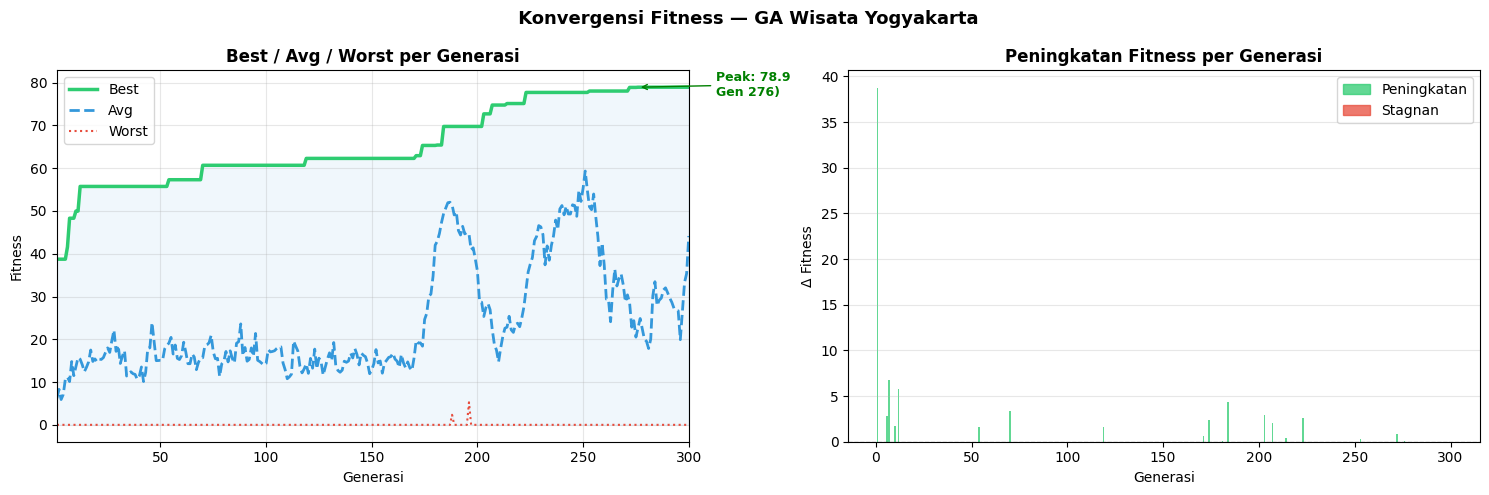

 Generasi berjalan: 300 | Best fitness: 78.92


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(' Konvergensi Fitness — GA Wisata Yogyakarta', fontsize=13, fontweight='bold')
gens = list(range(1, len(history['best']) + 1))
ax1 = axes[0]
ax1.plot(gens, history['best'],  color='#2ecc71', lw=2.5, label='Best')
ax1.plot(gens, history['avg'],   color='#3498db', lw=2,   label='Avg', linestyle='--')
ax1.plot(gens, history['worst'], color='#e74c3c', lw=1.5, label='Worst', linestyle=':')
ax1.fill_between(gens, history['worst'], history['best'], alpha=0.07, color='#3498db')
peak_gen = int(np.argmax(history['best'])) + 1
peak_val = max(history['best'])
ax1.annotate(f'Peak: {peak_val:.1f}\nGen {peak_gen})',
             xy=(peak_gen, peak_val),
             xytext=(peak_gen + max(3, len(gens)//8), peak_val - 2),
             arrowprops=dict(arrowstyle='->', color='green'),
             fontsize=9, color='green', fontweight='bold')
ax1.set_xlabel('Generasi'); ax1.set_ylabel('Fitness')
ax1.set_title('Best / Avg / Worst per Generasi', fontweight='bold')
ax1.legend(); ax1.grid(alpha=0.3); ax1.set_xlim(1, len(gens))

ax2 = axes[1]
delta       = np.diff([0] + history['best'])
bar_colors  = ['#2ecc71' if v > 0 else '#e74c3c' for v in delta]
ax2.bar(gens, delta, color=bar_colors, alpha=0.75)
ax2.axhline(0, color='black', lw=0.8, linestyle='--')
ax2.set_xlabel('Generasi'); ax2.set_ylabel('Δ Fitness')
ax2.set_title('Peningkatan Fitness per Generasi', fontweight='bold')
ax2.grid(alpha=0.3, axis='y')
ax2.legend(handles=[
    mpatches.Patch(color='#2ecc71', alpha=0.75, label='Peningkatan'),
    mpatches.Patch(color='#e74c3c', alpha=0.75, label='Stagnan')
])

plt.tight_layout()
plt.savefig('konvergensi_fitness.png', dpi=120, bbox_inches='tight')
plt.show()
print(f" Generasi berjalan: {len(gens)} | Best fitness: {peak_val:.2f}")

## Cell 10 — Output Rute & Jadwal

In [33]:
rute_terbaik, total_biaya, total_jarak, jadwal = decode_chromosome(best_chromosome)
fitness_terbaik = hitung_fitness(best_chromosome)

print(" ")
print("  HASIL TERBAIK ALGORITMA GENETIKA")
print("    Paket Wisata Yogyakarta — Rute Optimal")
print(" ")
print(f"  Fitness Score       : {fitness_terbaik:.2f}")
print(f"  Lokasi Dikunjungi   : {len(rute_terbaik)} dari {N} lokasi")
print(f"  Total Biaya         : Rp {total_biaya:,} / Rp {BUDGET_MAKS:,}")
print(f"  Sisa Budget         : Rp {BUDGET_MAKS - total_biaya:,}")
print(f"  Total Jarak         : {total_jarak} km")
print(f"  Kategori Unik       : {len(set(l['kategori'] for l in rute_terbaik))} kategori")
print(f"  Total Durasi        : {sum(l['durasi'] for l in rute_terbaik):.1f} jam")
print("=" * 68)

print("\nURUTAN RUTE:")
print("-" * 68)
print(f"  {'No':>3}  {'ID':<7} {'Nama Lokasi':<30} {'Kategori'}")
print("-" * 68)
for i, lok in enumerate(rute_terbaik):
    print(f"  {i+1:>3}. {lok['id_str']:<7} {lok['nama']:<30} {lok['kat_detail']}")

print("\nJADWAL PERJALANAN:")
print("-" * 78)
print(f"  {'No':>3}  {'Tiba':<7} {'Selesai':<8} {'ID':<7} {'Nama':<25} {'Biaya':>10} {'Jarak':>9}")
print("-" * 78)
biaya_kum = 0
for i, s in enumerate(jadwal):
    biaya_kum += s['harga']
    jarak_str = f"{s['jarak_dari_prev']} km" if i > 0 else "  Start"
    print(f"  {i+1:>3}. {s['jam_tiba']:<7} {s['jam_selesai']:<8} "
          f"{s['id_str']:<7} {s['nama']:<24} "
          f"Rp {s['harga']:>6,}  {jarak_str:>8}")
print("-" * 78)
print(f"  {'TOTAL':>48}  Rp {biaya_kum:>6,}  {total_jarak:>6} km")

# Analisis kualitas urutan
kat_list = [l['kategori'] for l in rute_terbaik]
n_same   = sum(1 for i in range(len(kat_list)-1) if kat_list[i]==kat_list[i+1])
n_mirip  = sum(1 for i in range(len(kat_list)-1)
               for g in SIMILAR_GROUPS
               if kat_list[i] in g and kat_list[i+1] in g and kat_list[i]!=kat_list[i+1])
print(f"\nAnalisis Kualitas:")
print(f"   Kategori sama berurutan  : {n_same}x")
print(f"   Kategori mirip berurutan : {n_mirip}x")

 
  HASIL TERBAIK ALGORITMA GENETIKA
    Paket Wisata Yogyakarta — Rute Optimal
 
  Fitness Score       : 78.92
  Lokasi Dikunjungi   : 7 dari 50 lokasi
  Total Biaya         : Rp 80,000 / Rp 150,000
  Sisa Budget         : Rp 70,000
  Total Jarak         : 38.15 km
  Kategori Unik       : 4 kategori
  Total Durasi        : 9.5 jam

URUTAN RUTE:
--------------------------------------------------------------------
   No  ID      Nama Lokasi                    Kategori
--------------------------------------------------------------------
    1. S0003   Benteng Vredeburg              Sejarah / Museum
    2. I0002   Tugu Yogyakarta                Ikonik
    3. S0007   Museum Affandi                 Sejarah / Museum
    4. I0003   Titik Nol Kilometer            Ikonik
    5. H0001   Alun-Alun Kidul                Hiburan Malam
    6. I0001   Jalan Malioboro                Belanja / Ikonik
    7. A0001   Tebing Breksi                  Alam / Spot Foto

JADWAL PERJALANAN:
---------------------

## Cell 11 — Visualisasi Peta & Statistik

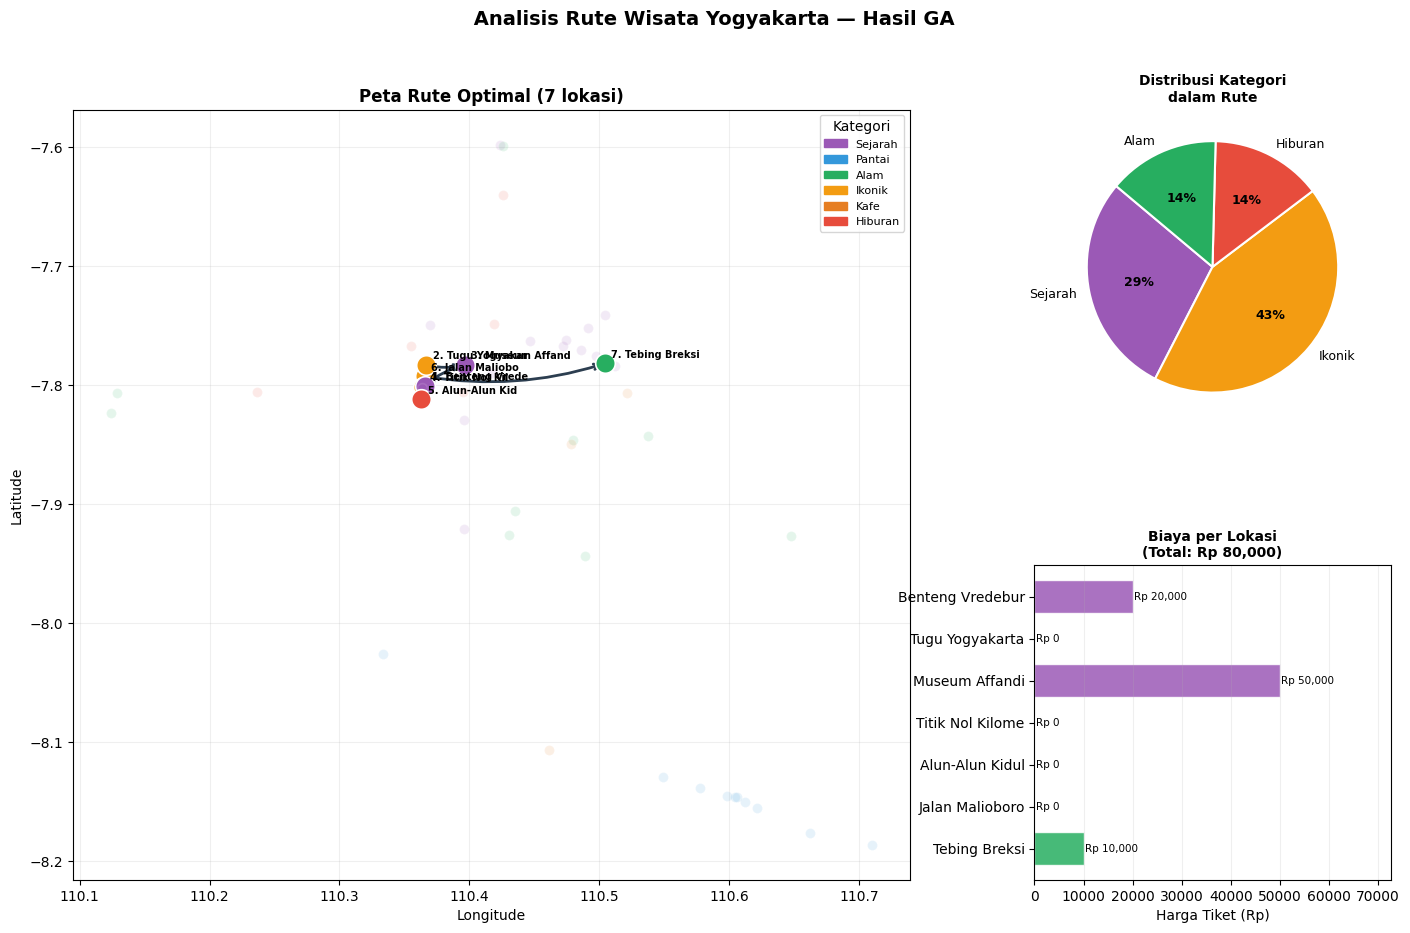

✅ Visualisasi selesai!


In [37]:
coords   = df[['lat', 'lon']].values
visited  = [lok['idx'] for lok in rute_terbaik]

fig = plt.figure(figsize=(17, 10))
gs  = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle(' Analisis Rute Wisata Yogyakarta — Hasil GA',
             fontsize=14, fontweight='bold')

# Peta
ax_map = fig.add_subplot(gs[0:2, 0:2])
for i in range(N):
    kat   = df.iloc[i]['kategori_utama']
    color = WARNA_KAT.get(kat, 'gray')
    alpha = 1.0 if i in visited else 0.12
    size  = 200 if i in visited else 50
    ax_map.scatter(coords[i][1], coords[i][0],
                   s=size, color=color, alpha=alpha,
                   zorder=3, edgecolors='white', linewidth=1.2)
    if i in visited:
        rank = visited.index(i) + 1
        ax_map.text(coords[i][1]+0.005, coords[i][0]+0.005,
                    f"{rank}. {df.iloc[i]['nama_lokasi'][:13]}",
                    fontsize=7, fontweight='bold', zorder=4)

for i in range(len(visited)-1):
    a, b = visited[i], visited[i+1]
    ax_map.annotate("",
        xy=(coords[b][1], coords[b][0]),
        xytext=(coords[a][1], coords[a][0]),
        arrowprops=dict(arrowstyle='->', color='#2c3e50',
                        lw=2.0, connectionstyle='arc3,rad=0.12'),
        zorder=2)

ax_map.legend(handles=[mpatches.Patch(color=c, label=k)
                        for k, c in WARNA_KAT.items()],
              loc='upper right', fontsize=8, title='Kategori')
ax_map.set_xlabel('Longitude'); ax_map.set_ylabel('Latitude')
ax_map.set_title(f'Peta Rute Optimal ({len(rute_terbaik)} lokasi)', fontweight='bold')
ax_map.grid(alpha=0.2)

# Pie chart kategori
ax_cat = fig.add_subplot(gs[0, 2])
kat_count = Counter(l['kategori'] for l in rute_terbaik)
wedges, texts, auts = ax_cat.pie(
    kat_count.values(),
    labels=kat_count.keys(),
    colors=[WARNA_KAT.get(k,'gray') for k in kat_count],
    autopct='%1.0f%%', startangle=140,
    wedgeprops={'edgecolor':'white','linewidth':1.5},
    textprops={'fontsize':9})
for at in auts: at.set_fontweight('bold')
ax_cat.set_title('Distribusi Kategori\ndalam Rute', fontsize=10, fontweight='bold')

# Bar biaya
ax_cost = fig.add_subplot(gs[1, 2])
if total_biaya == 0:
    ax_cost.text(0.5, 0.5, "Semua lokasi gratis\n(Total Biaya: Rp 0)",
                 horizontalalignment='center', verticalalignment='center',
                 transform=ax_cost.transAxes, fontsize=10, color='gray')
    ax_cost.set_xticks([])
    ax_cost.set_yticks([])
    ax_cost.set_frame_on(False)
    ax_cost.set_title(f'Biaya per Lokasi', fontsize=10, fontweight='bold')
else:
    names_s = [l['nama'][:16] for l in rute_terbaik]
    harga_l = [l['harga'] for l in rute_terbaik]
    bc      = [WARNA_KAT.get(l['kategori'],'gray') for l in rute_terbaik]
    bars    = ax_cost.barh(names_s, harga_l, color=bc, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, harga_l):
        ax_cost.text(bar.get_width()+300, bar.get_y()+bar.get_height()/2,
                     f'Rp {val:,}', va='center', fontsize=7.5)
    ax_cost.set_xlabel('Harga Tiket (Rp)')
    ax_cost.set_title(f'Biaya per Lokasi\n(Total: Rp {total_biaya:,})',
                      fontsize=10, fontweight='bold')
    ax_cost.set_xlim(0, max(harga_l)*1.45)
    ax_cost.invert_yaxis(); ax_cost.grid(alpha=0.2, axis='x')

plt.savefig('rute_visualisasi.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Visualisasi selesai!")